# Count all vertices in a Shapefile with GeoPandas

In [1]:
import geopandas as gpd
import pandas as pd

In [3]:
shpfil = gpd.read_file('../example_data/cb_2018_us_state_20m/cb_2018_us_state_20m.shp')

In [5]:
shpfil.loc[3]

STATEFP                                                    39
STATENS                                              01085497
AFFGEOID                                          0400000US39
GEOID                                                      39
STUSPS                                                     OH
NAME                                                     Ohio
LSAD                                                       00
ALAND                                            105828882568
AWATER                                            10268850702
geometry    MULTIPOLYGON (((-82.863342 41.693692999999996,...
Name: 3, dtype: object

In [7]:
shpfil_reix = shpfil.set_index("STUSPS")
shpfil_reix

,STATEFP,STATENS,AFFGEOID,GEOID,NAME,LSAD,ALAND,AWATER,geometry
STUSPS,,,,,,,,,
MD,24,01714934,0400000US24,24,Maryland,00,25151100280,6979966958,"MULTIPOLYGON (((-76.04621 38.02553, -76.00734 ..."
IA,19,01779785,0400000US19,19,Iowa,00,144661267977,1084180812,"POLYGON ((-96.62187 42.77926, -96.57794 42.827..."
DE,10,01779781,0400000US10,10,Delaware,00,5045925646,1399985648,"POLYGON ((-75.77379 39.7222, -75.75323 39.7579..."
OH,39,01085497,0400000US39,39,Ohio,00,105828882568,10268850702,"MULTIPOLYGON (((-82.86334 41.69369, -82.82572 ..."
PA,42,01779798,0400000US42,42,Pennsylvania,00,115884442321,3394589990,"POLYGON ((-80.51989 40.90666, -80.51964 40.987..."
NE,31,01779792,0400000US31,31,Nebraska,00,198956658395,1371829134,"POLYGON ((-104.05314 41.11446, -104.05245 41.2..."
WA,53,01779804,0400000US53,53,Washington,00,172112588220,12559278850,"MULTIPOLYGON (((-123.23715 48.68347, -123.0704..."
PR,72,01779808,0400000US72,72,Puerto Rico,00,8868896030,4922382562,"MULTIPOLYGON (((-65.34207 18.34529, -65.25593 ..."
AL,01,01779775,0400000US01,01,Alabama,00,131174048583,4593327154,"POLYGON ((-88.46866 31.89386, -88.46866 31.933..."


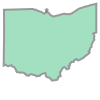

In [12]:
shpfil_reix.loc['OH'].geometry

In [17]:
shpfil_reix.to_crs(epsg=2263).loc['OH'].geometry.area


1151833457757.393

In [10]:
def count_vertices(geom):
    if geom.geom_type == "Polygon":
        return len(geom.exterior.coords) - 1
    elif geom.geom_type == "MultiPolygon":
        return sum(len(p.exterior.coords) - 1 for p in geom.geoms)
    return 0


In [11]:
shpfil["vertex_count"] = shpfil.geometry.apply(count_vertices)


In [13]:
shpfil['vertex_count'].sum()

np.int64(13658)